In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (18, 6)
plt.rcParams['figure.dpi'] = 100

In [2]:
# Paths relative to the project root
PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath("__file__"))) if "__file__" in dir() else os.getcwd()
# Adjust if running from within the test/ folder
if os.path.basename(PROJECT_ROOT) == 'test':
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)

DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
TRAIN_DIR = os.path.join(DATA_DIR, 'raw', 'train')
TEST_DIR = os.path.join(DATA_DIR, 'raw', 'test')
LABELED_CSV = os.path.join(DATA_DIR, 'processed', 'labeled_anomalies.csv')

print(f"Project root: {PROJECT_ROOT}")
print(f"Train dir exists: {os.path.exists(TRAIN_DIR)}")
print(f"Test dir exists:  {os.path.exists(TEST_DIR)}")
print(f"Labeled CSV exists: {os.path.exists(LABELED_CSV)}")

Project root: c:\Users\andre\OneDrive\Desktop\Single Pass TCN Autoencoder
Train dir exists: True
Test dir exists:  True
Labeled CSV exists: True


In [3]:
# Load labeled anomalies and build channel list
df_labels = pd.read_csv(LABELED_CSV)

def parse_sequences(seq_str):
    return json.loads(seq_str)

def parse_classes(cls_str):
    return [s.strip() for s in cls_str.strip("[]").split(",")]

df_labels['anomaly_sequences'] = df_labels['anomaly_sequences'].apply(parse_sequences)
df_labels['class'] = df_labels['class'].apply(parse_classes)

# Filter to channels that have both train and test data
available_channels = []
for _, row in df_labels.iterrows():
    ch = row['chan_id']
    train_path = os.path.join(TRAIN_DIR, f'{ch}.npy')
    test_path = os.path.join(TEST_DIR, f'{ch}.npy')
    if os.path.exists(train_path) and os.path.exists(test_path):
        available_channels.append(ch)

available_channels = sorted(available_channels)

print(f"Total channels with labels: {len(df_labels)}")
print(f"Channels with both train & test data: {len(available_channels)}")
print(f"Available channels: {available_channels}")

Total channels with labels: 82
Channels with both train & test data: 82
Available channels: ['A-1', 'A-2', 'A-3', 'A-4', 'A-5', 'A-6', 'A-7', 'A-8', 'A-9', 'B-1', 'C-1', 'C-2', 'D-1', 'D-11', 'D-12', 'D-13', 'D-14', 'D-15', 'D-16', 'D-2', 'D-3', 'D-4', 'D-5', 'D-6', 'D-7', 'D-8', 'D-9', 'E-1', 'E-10', 'E-11', 'E-12', 'E-13', 'E-2', 'E-3', 'E-4', 'E-5', 'E-6', 'E-7', 'E-8', 'E-9', 'F-1', 'F-2', 'F-3', 'F-4', 'F-5', 'F-7', 'F-8', 'G-1', 'G-2', 'G-3', 'G-4', 'G-6', 'G-7', 'M-1', 'M-2', 'M-3', 'M-4', 'M-5', 'M-6', 'M-7', 'P-1', 'P-10', 'P-11', 'P-14', 'P-15', 'P-2', 'P-2', 'P-3', 'P-4', 'P-7', 'R-1', 'S-1', 'S-2', 'T-1', 'T-12', 'T-13', 'T-2', 'T-3', 'T-4', 'T-5', 'T-8', 'T-9']


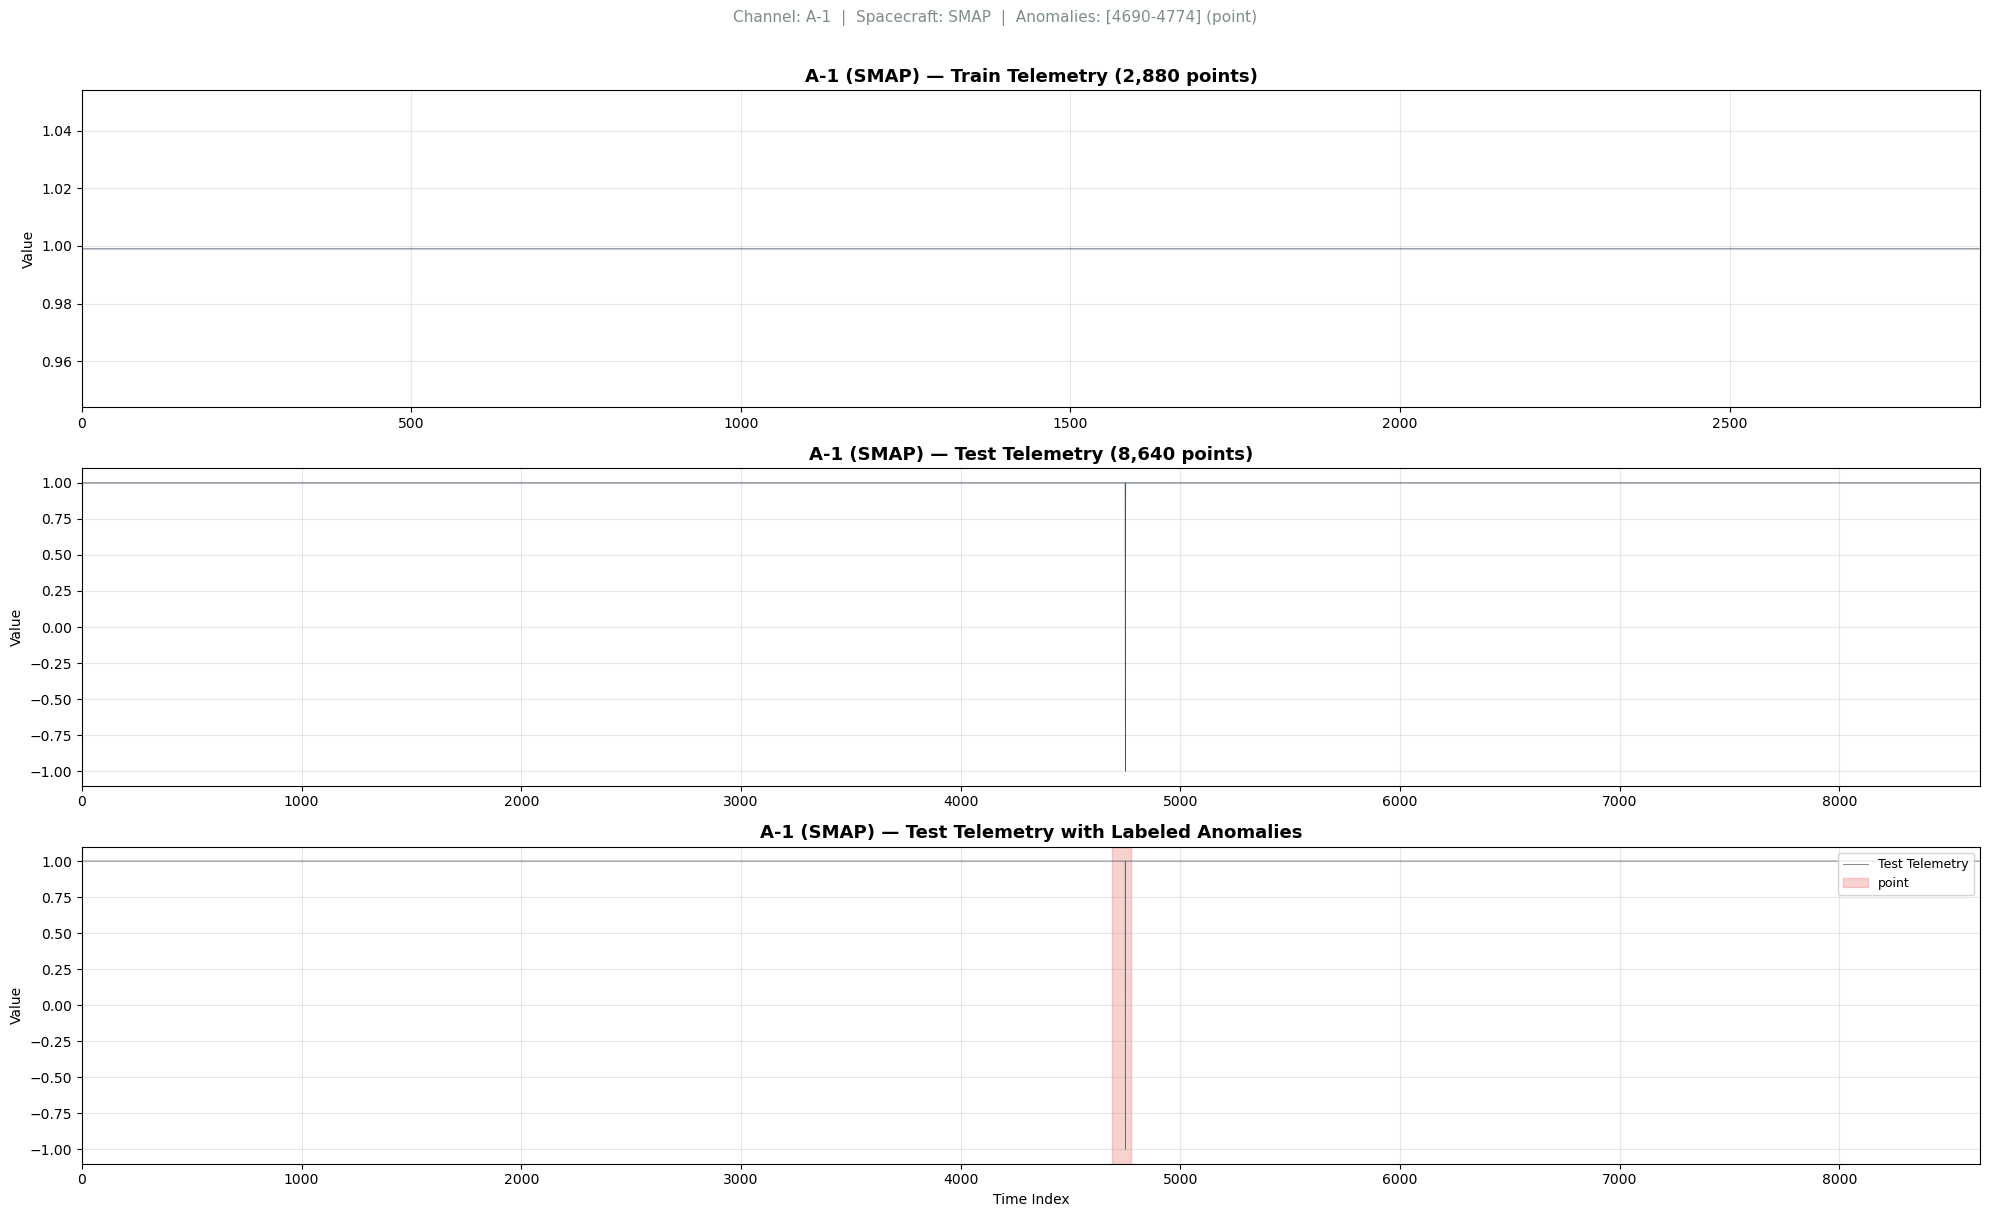


Train: 2,880 pts  |  Test: 8,640 pts  |  Anomaly regions: 1
  • [  4690 –   4774]  length=   84  class=point


In [4]:
def plot_channel(channel):
    """Load and plot train, test, and anomalies for a given channel."""
    
    if channel not in available_channels:
        print(f"ERROR: '{channel}' not found. Available: {available_channels}")
        return
    
    # Load data
    train_data = np.load(os.path.join(TRAIN_DIR, f'{channel}.npy'))
    test_data = np.load(os.path.join(TEST_DIR, f'{channel}.npy'))
    
    # Extract telemetry (column 0 if 2D, else the whole array)
    if train_data.ndim == 2 and train_data.shape[1] > 0:
        train_telemetry = train_data[:, 0].flatten()
    else:
        train_telemetry = train_data.flatten()
    
    if test_data.ndim == 2 and test_data.shape[1] > 0:
        test_telemetry = test_data[:, 0].flatten()
    else:
        test_telemetry = test_data.flatten()
    
    # Get anomaly info
    row = df_labels[df_labels['chan_id'] == channel].iloc[0]
    anomaly_seqs = row['anomaly_sequences']
    anomaly_classes = row['class']
    spacecraft = row['spacecraft']
    
    class_colors = {
        'point': '#e74c3c',
        'contextual': '#e67e22'
    }
    
    fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=False)
    
    # Plot 1: Train Telemetry
    ax = axes[0]
    ax.plot(train_telemetry, color='#2c3e50', linewidth=0.6, alpha=0.9)
    ax.set_title(f'{channel} ({spacecraft}) \u2014 Train Telemetry ({len(train_telemetry):,} points)',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, len(train_telemetry))
    
    # Plot 2: Test Telemetry
    ax = axes[1]
    ax.plot(test_telemetry, color='#2c3e50', linewidth=0.6, alpha=0.9)
    ax.set_title(f'{channel} ({spacecraft}) \u2014 Test Telemetry ({len(test_telemetry):,} points)',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, len(test_telemetry))
    
    # Plot 3: Test Telemetry with Labeled Anomalies
    ax = axes[2]
    ax.plot(test_telemetry, color='#2c3e50', linewidth=0.6, alpha=0.7, label='Test Telemetry')
    
    seen_classes = set()
    for i, (start, end) in enumerate(anomaly_seqs):
        cls = anomaly_classes[i]
        color = class_colors.get(cls, '#c0392b')
        label = cls if cls not in seen_classes else None
        seen_classes.add(cls)
        ax.axvspan(start, end, alpha=0.25, color=color, label=label)
    
    ax.legend(loc='upper right', fontsize=9)
    ax.set_title(f'{channel} ({spacecraft}) \u2014 Test Telemetry with Labeled Anomalies',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Time Index')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, len(test_telemetry))
    
    anomaly_text = "  |  ".join([f"[{s}-{e}] ({c})" for (s, e), c in zip(anomaly_seqs, anomaly_classes)])
    fig.suptitle(f'Channel: {channel}  |  Spacecraft: {spacecraft}  |  Anomalies: {anomaly_text}',
                 fontsize=11, y=1.01, color='#7f8c8d')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nTrain: {len(train_telemetry):,} pts  |  Test: {len(test_telemetry):,} pts  |  "
          f"Anomaly regions: {len(anomaly_seqs)}")
    for (s, e), c in zip(anomaly_seqs, anomaly_classes):
        print(f"  \u2022 [{s:>6} \u2013 {e:>6}]  length={e-s:>5}  class={c}")


# Demo: plot the first available channel
plot_channel(available_channels[0])

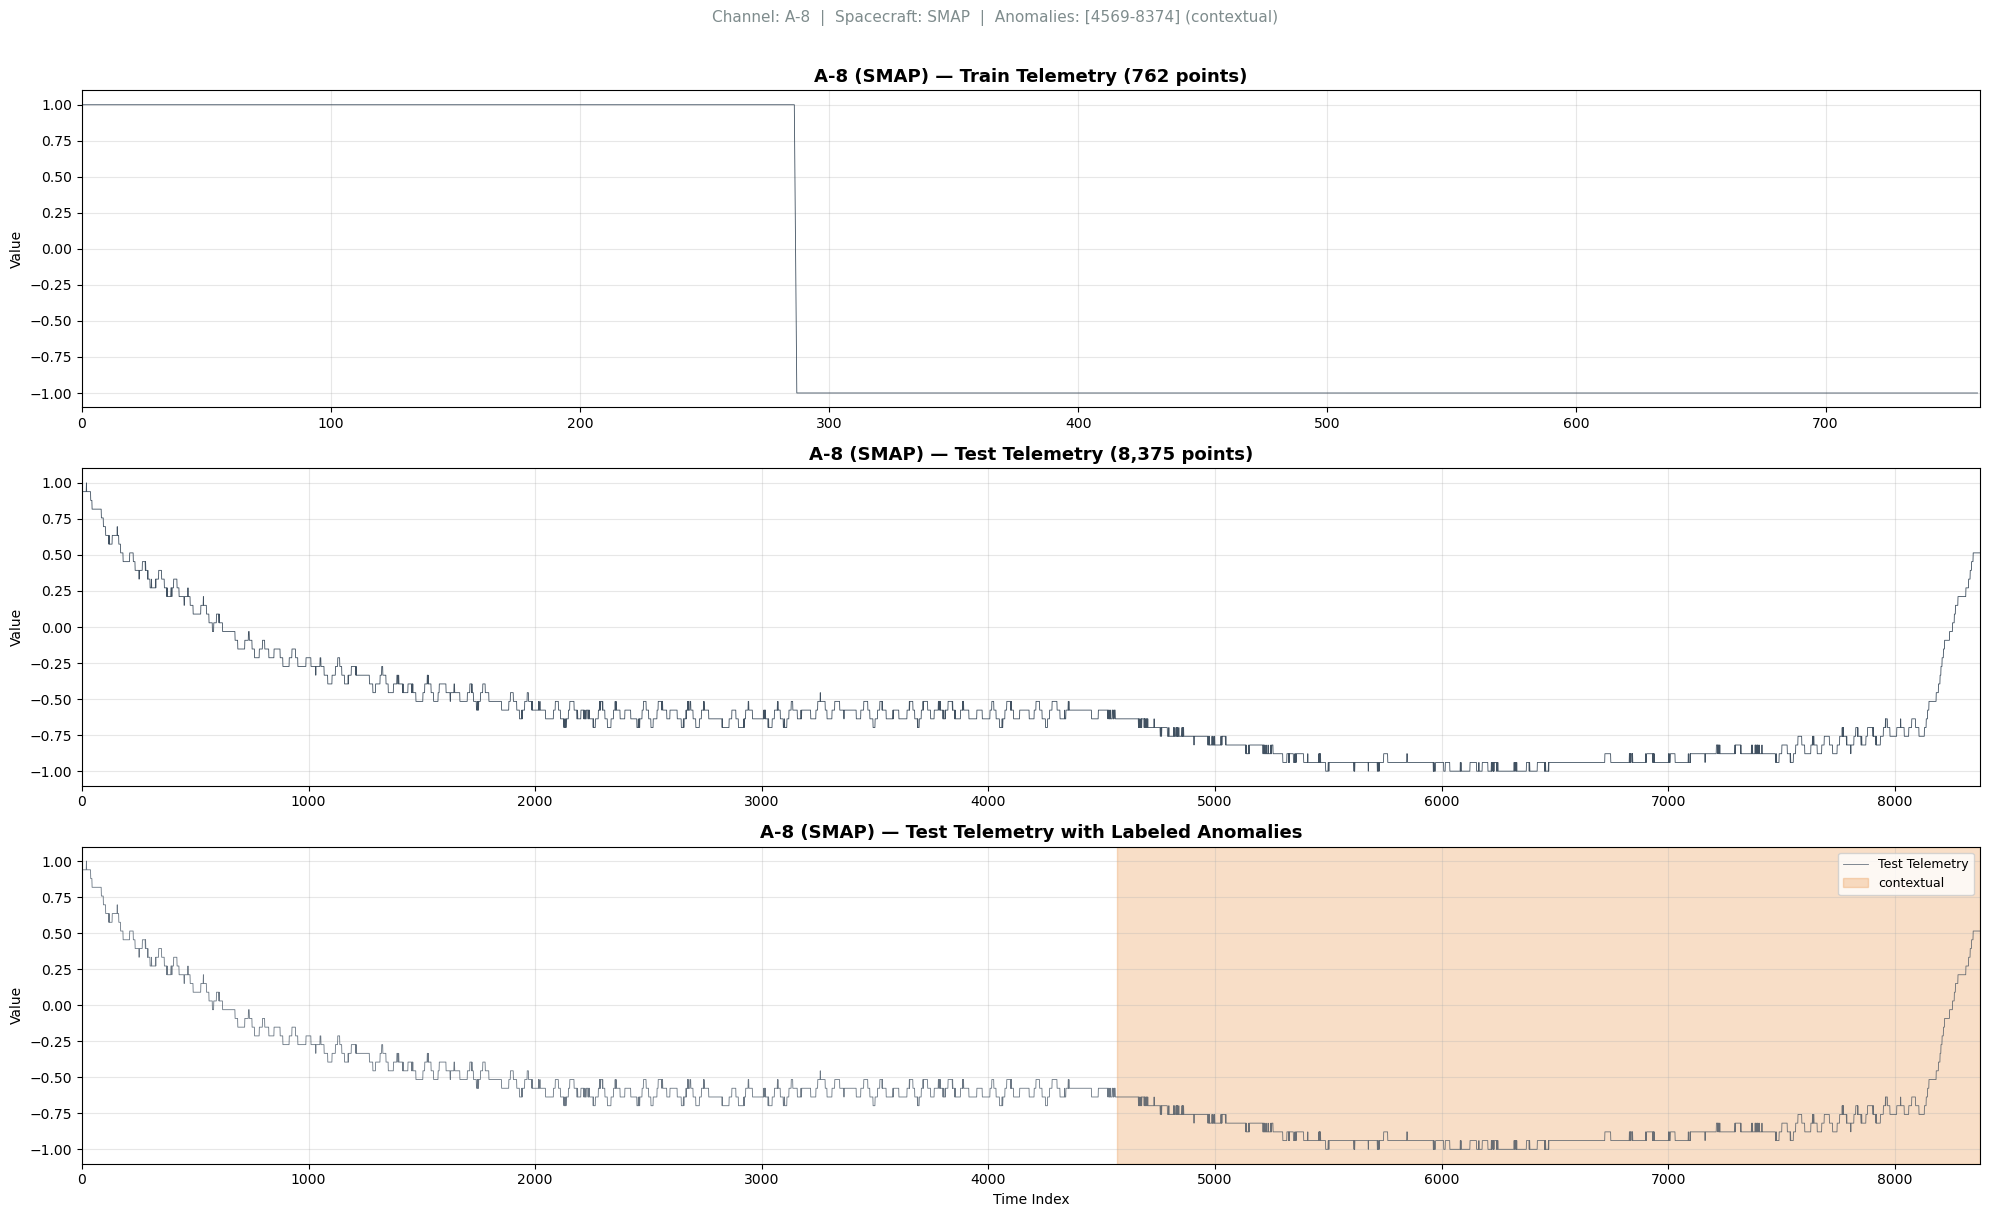


Train: 762 pts  |  Test: 8,375 pts  |  Anomaly regions: 1
  • [  4569 –   8374]  length= 3805  class=contextual


In [ ]:
# To view a different channel, call plot_channel() with the channel name:
#   plot_channel("A-1")
#   plot_channel("D-4")
#   plot_channel("F-7")

plot_channel("A-8")

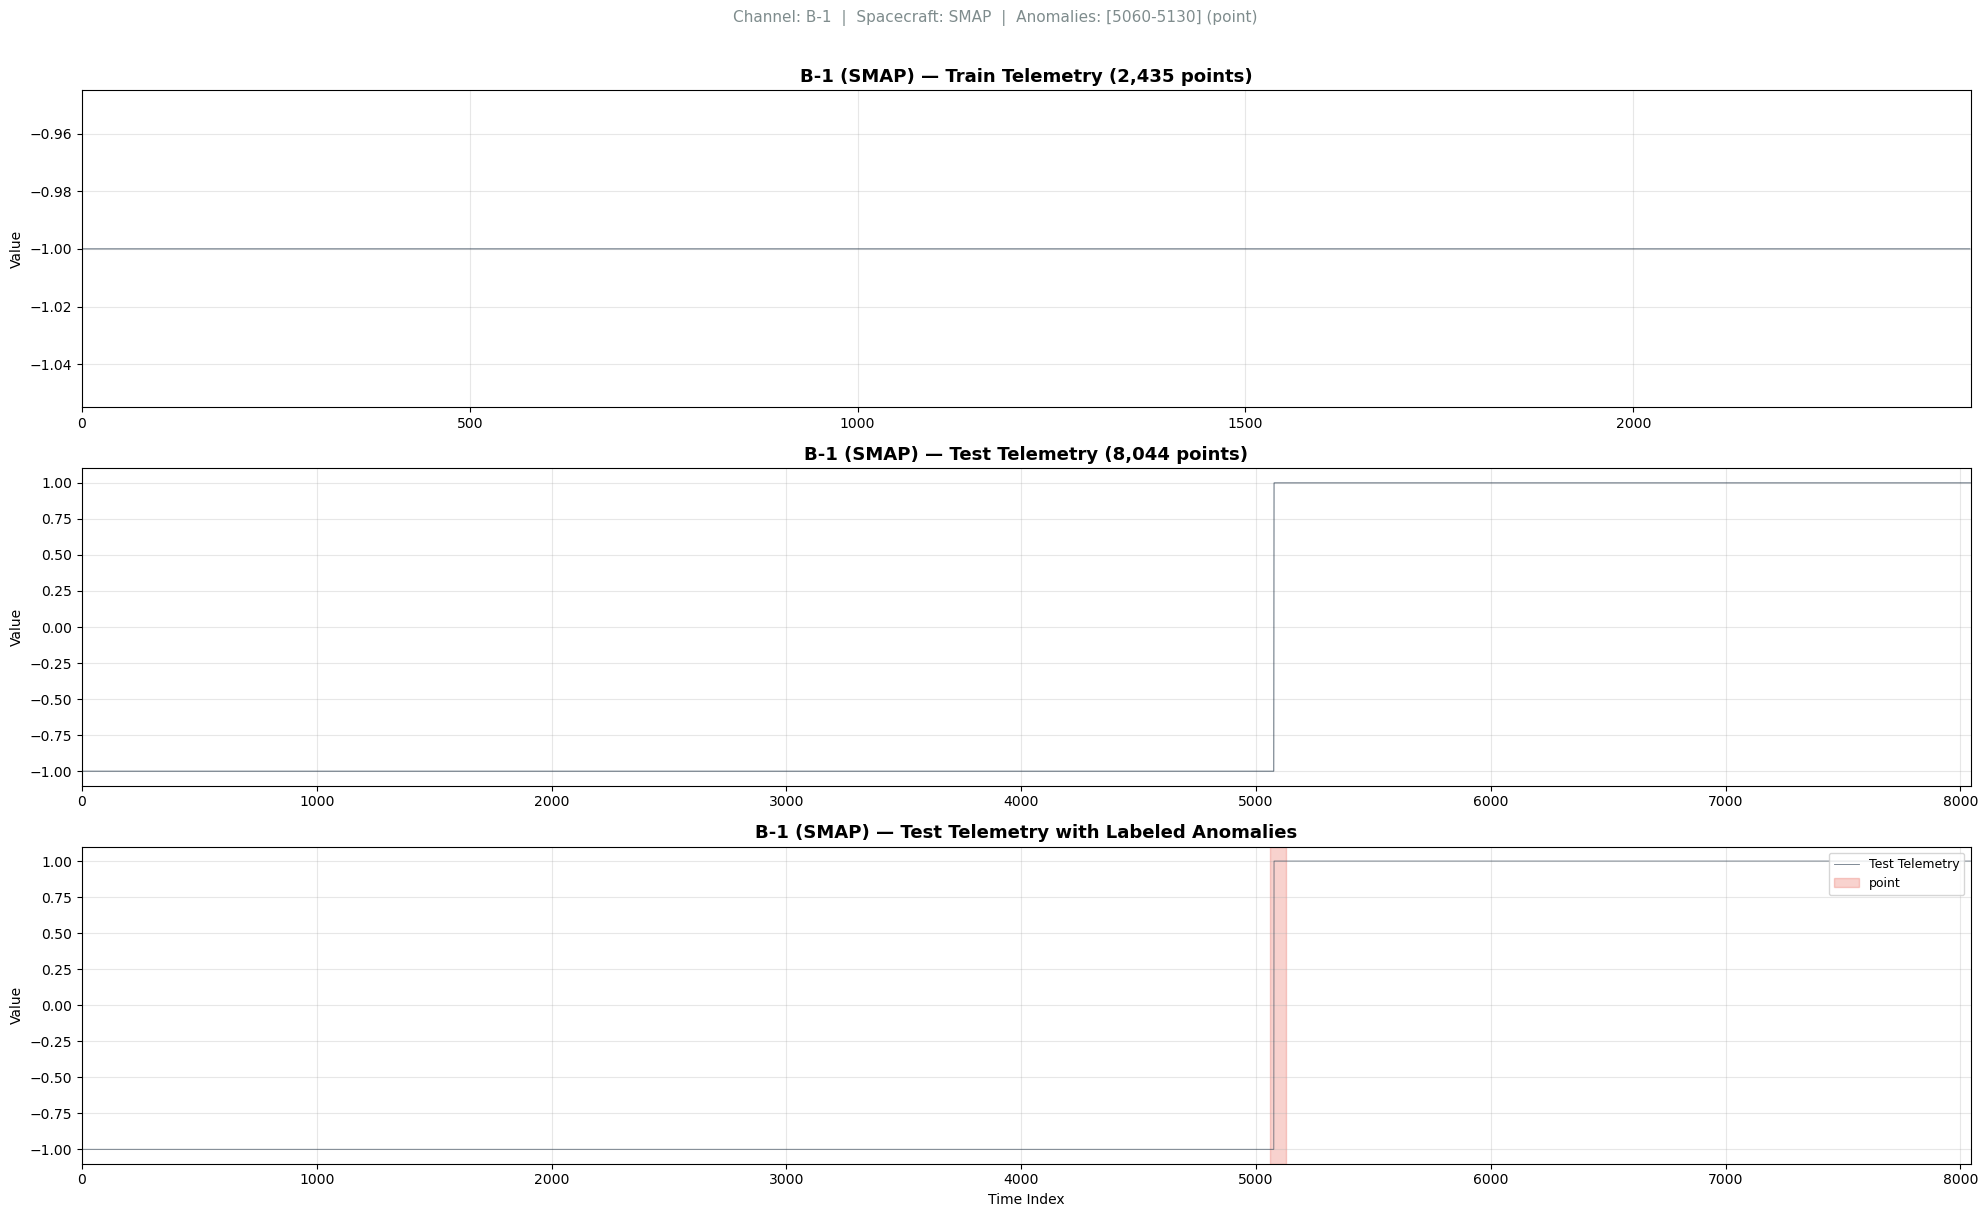


Train: 2,435 pts  |  Test: 8,044 pts  |  Anomaly regions: 1
  • [  5060 –   5130]  length=   70  class=point


In [13]:
plot_channel(available_channels[9])

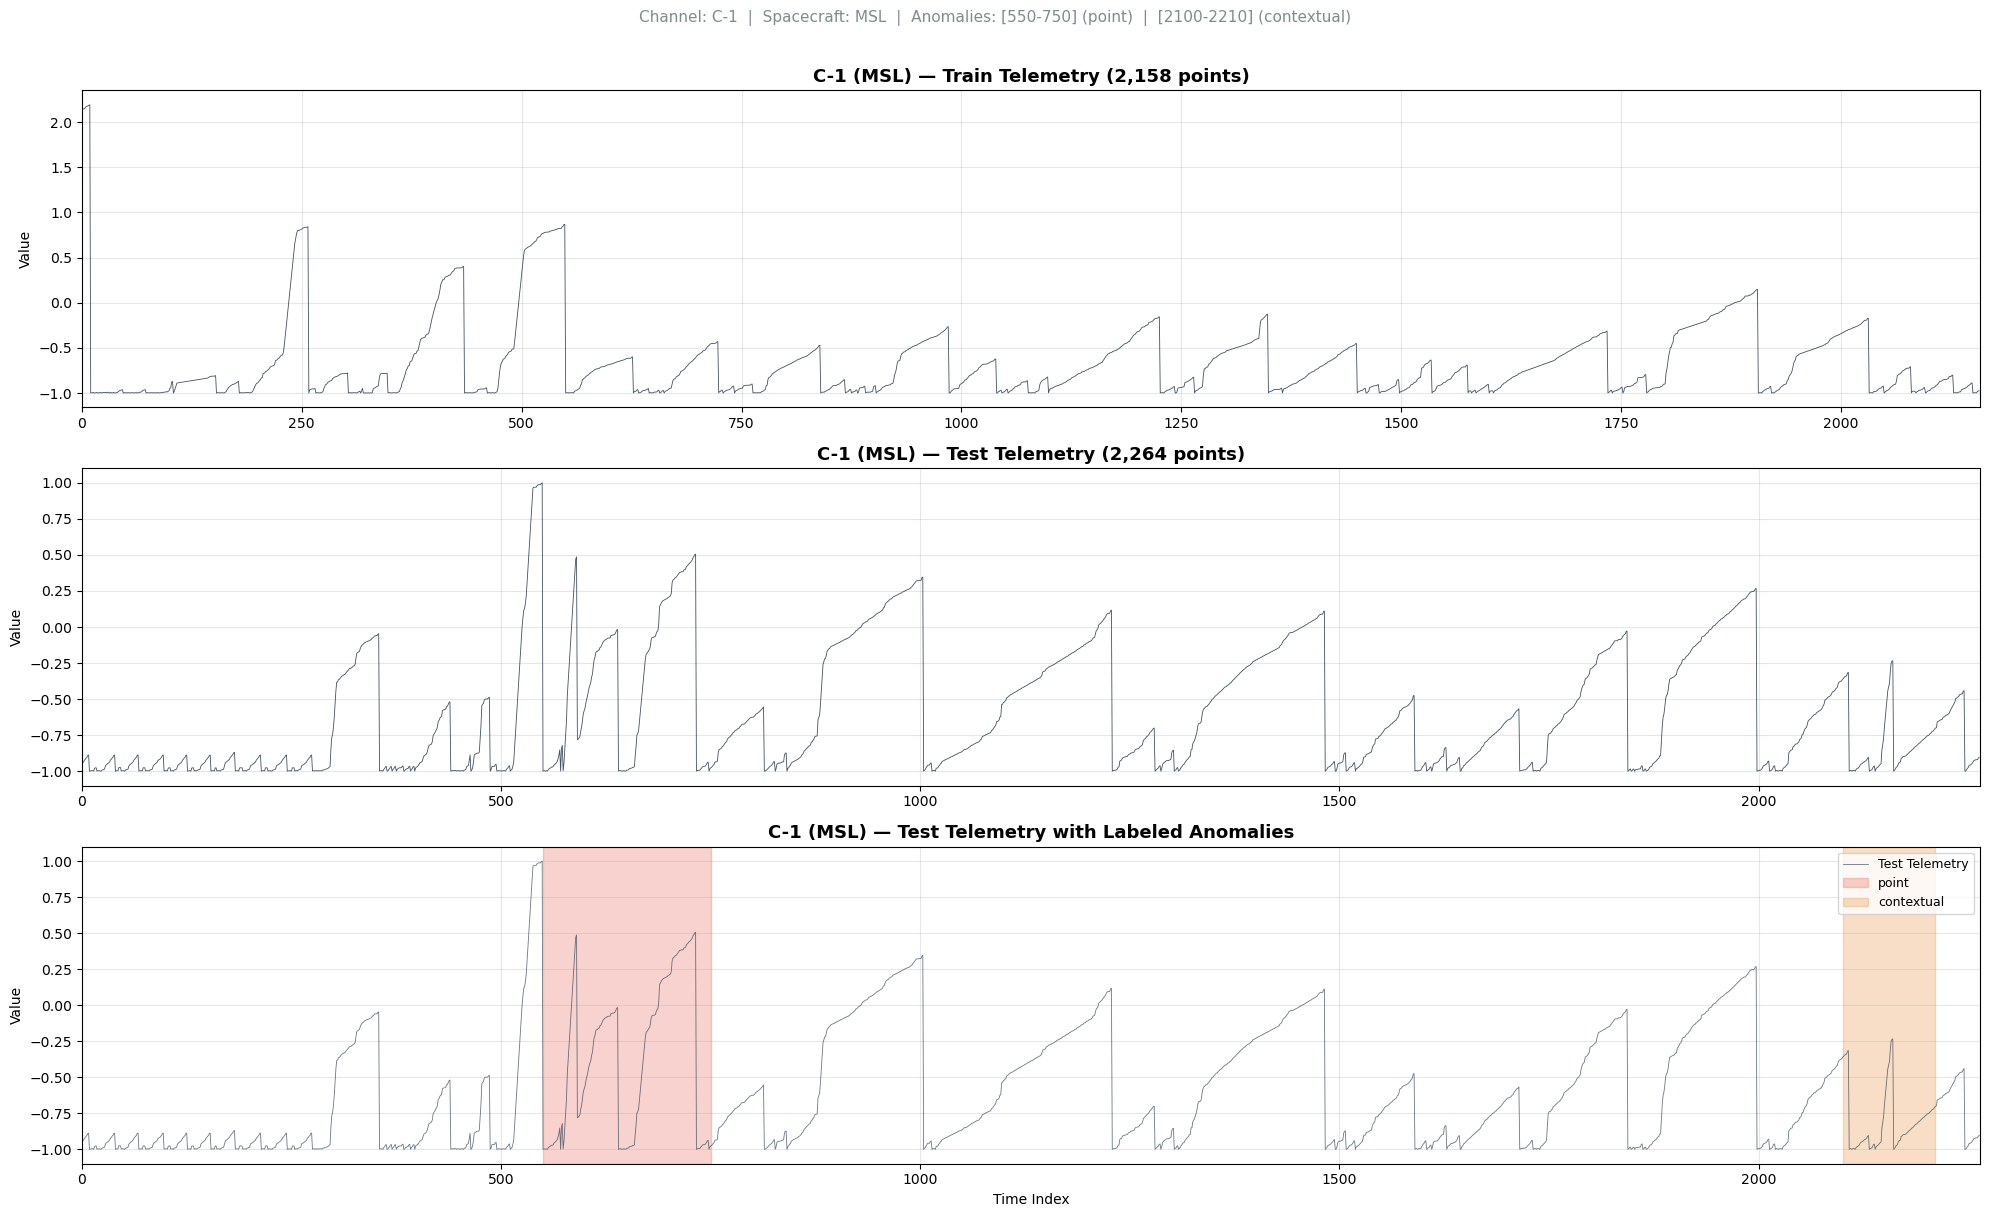


Train: 2,158 pts  |  Test: 2,264 pts  |  Anomaly regions: 2
  • [   550 –    750]  length=  200  class=point
  • [  2100 –   2210]  length=  110  class=contextual


In [14]:
plot_channel(available_channels[10])

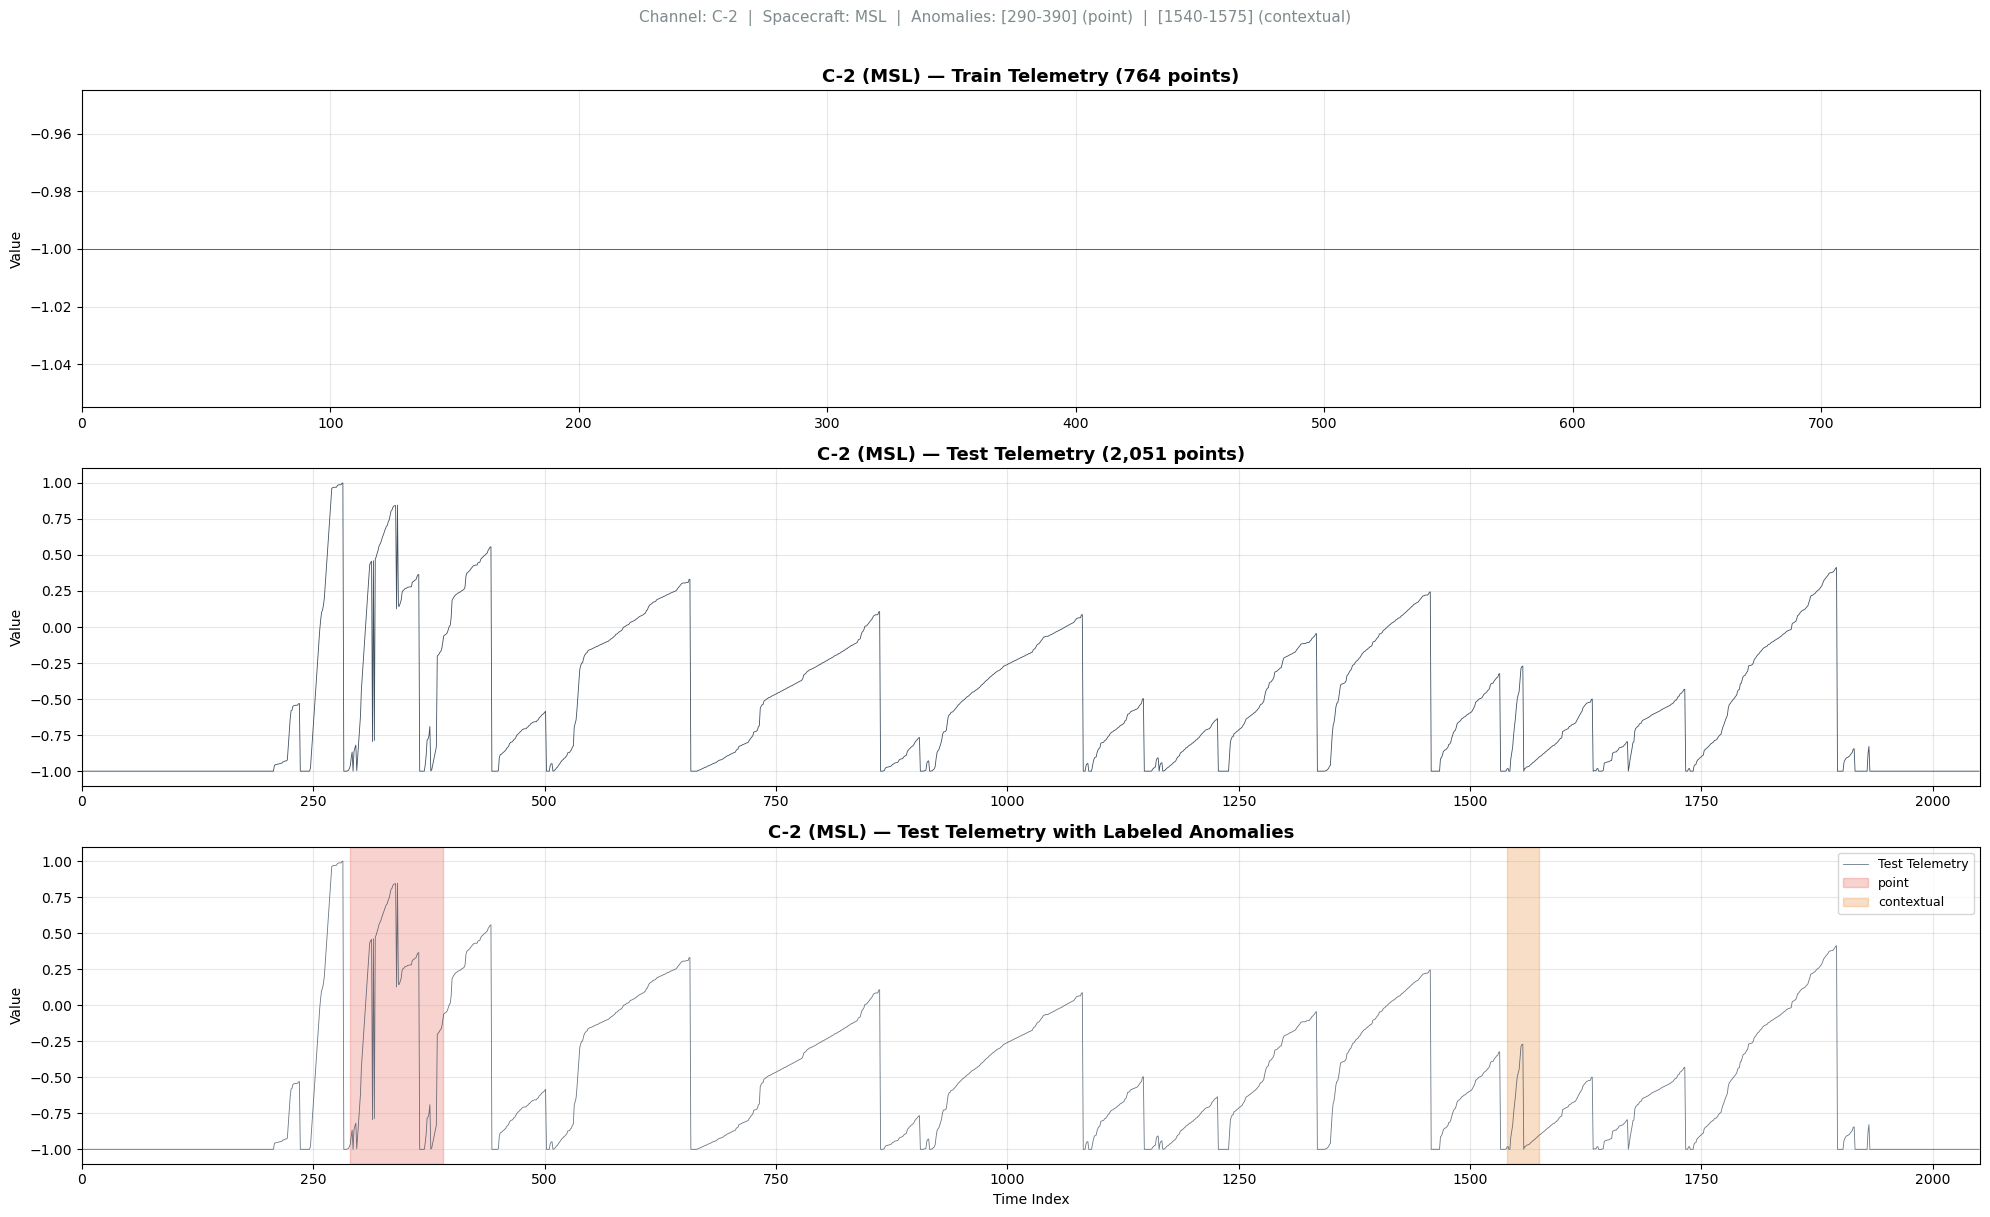


Train: 764 pts  |  Test: 2,051 pts  |  Anomaly regions: 2
  • [   290 –    390]  length=  100  class=point
  • [  1540 –   1575]  length=   35  class=contextual


In [16]:
plot_channel(available_channels[11])